In [36]:
import matplotlib as mpl
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
import sklearn
import pandas as pd
import os
import sys
import time
from tqdm.auto import tqdm
import torch
import torch.nn as nn
import torch.nn.functional as F

In [37]:
print(sys.version_info)
for module in mpl, np, pd, sklearn, torch:
    print(module.__name__, module.__version__)

sys.version_info(major=3, minor=12, micro=3, releaselevel='final', serial=0)
matplotlib 3.10.8
numpy 1.26.4
pandas 2.3.3
sklearn 1.8.0
torch 2.9.1+cpu


In [38]:
device = torch.device("cuda:0") if torch.cuda.is_available() else torch.device("cpu")
print(device)

cpu


# 准备数据

In [39]:
from sklearn.datasets import fetch_california_housing

housing = fetch_california_housing(data_home='data')
print(housing.DESCR)
print(housing.data.shape)
print(housing.target.shape)

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

In [40]:
import pprint  #打印的格式比较 好看

pprint.pprint(housing.data[0:2])
print('-' * 50)
pprint.pprint(housing.target[0:2])

array([[ 8.32520000e+00,  4.10000000e+01,  6.98412698e+00,
         1.02380952e+00,  3.22000000e+02,  2.55555556e+00,
         3.78800000e+01, -1.22230000e+02],
       [ 8.30140000e+00,  2.10000000e+01,  6.23813708e+00,
         9.71880492e-01,  2.40100000e+03,  2.10984183e+00,
         3.78600000e+01, -1.22220000e+02]])
--------------------------------------------------
array([4.526, 3.585])


## 拆分成训练集，验证集，测试集

In [41]:
from sklearn.model_selection import train_test_split

#拆分训练集和测试集，random_state是随机种子,同样的随机数种子，是为了得到同样的随机值
x_train_all, x_test, y_train_all, y_test = train_test_split(
    housing.data, housing.target, random_state=7)
x_train, x_valid, y_train, y_valid = train_test_split(
    x_train_all, y_train_all, random_state=11)
# 训练集
print(x_train.shape, y_train.shape)
# 验证集
print(x_valid.shape, y_valid.shape)
# 测试集
print(x_test.shape, y_test.shape)

dataset_maps = {
    "train": [x_train, y_train],
    "valid": [x_valid, y_valid],
    "test": [x_test, y_test],
}  #把3个数据集都放到字典中

(11610, 8) (11610,)
(3870, 8) (3870,)
(5160, 8) (5160,)


## 对训练集进行标准化

In [42]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()  #标准化
scaler.fit(x_train)  #fit和fit_transform的区别，fit是计算均值和方差，fit_transform是先fit，然后transform
type(x_train)

numpy.ndarray

# 构建数据集

In [43]:
#构建私有数据集，就需要用如下方式
from torch.utils.data import Dataset


class HousingDataset(Dataset):
    def __init__(self, dataset, mode="train"):
        self.x, self.y = dataset[mode]  #x,y都是ndarray类型
        self.x = torch.from_numpy(scaler.transform(self.x)).float()  #from_numpy将NumPy数组转换成PyTorch张量
        self.y = torch.from_numpy(self.y).float().reshape(-1, 1)  #from_numpy将NumPy数组转换成PyTorch张量

    def __len__(self):  #必须写
        return len(self.x)  #返回数据集的长度,0维的size

    def __getitem__(self, index):
        return self.x[index], self.y[index]  #idx是索引，返回的是数据和标签，这里是一个样本


# train_ds是dataset类型的数据，与前面例子的FashionMNIST类型一致   
train_ds = HousingDataset(dataset_maps, "train")
valid_ds = HousingDataset(dataset_maps, "valid")
test_ds = HousingDataset(dataset_maps, "test")

In [44]:
train_ds[0]

(tensor([ 0.8015,  0.2722, -0.1162, -0.2023, -0.5431, -0.0210, -0.5898, -0.0824]),
 tensor([3.2260]))

In [45]:
train_ds[0][0]

tensor([ 0.8015,  0.2722, -0.1162, -0.2023, -0.5431, -0.0210, -0.5898, -0.0824])

# DataLorder

In [46]:
from torch.utils.data import DataLoader

#放到DataLoader中的train_ds, valid_ds, test_ds都是dataset类型的数据
batch_size = 16
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(valid_ds, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

# 定义模型结构

In [47]:
#回归模型我们只需要1个数

class NeuralNetwork(nn.Module):
    def __init__(self, input_dim=8):
        super().__init__()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(input_dim, 30),
            nn.ReLU(),
            nn.Linear(30, 1)
        )

    def forward(self, x):
        # x.shape [batch size, input_dim]
        logits = self.linear_relu_stack(x)
        # logits.shape [batch size, 1]
        return logits

# 评估模型

In [48]:
@torch.no_grad()
def evaluator(model, data_loader, loss_func):
    loss_list = []

    for data, label in data_loader:
        data = data.to(device)
        label = label.to(device)
        logits = model(data)
        loss = loss_func(logits, label)
        loss_list.append(loss.item())

    return np.mean(loss_list)


# Early Stop

In [49]:
class EarlyStopCallback:
    def __init__(self, patience=5, min_delta=0.01):
        """
        Early stop callback.
        :param patience: how many epochs to wait before stopping when loss is not improving. Defaults to 5.
        :param min_delta: minimum change in the monitored quantity to qualify as an improvement. Defaults to 0.01.
        """
        self.patience = patience  # 多少个epoch没有提升就停止训练
        self.min_delta = min_delta  # 最小的提升幅度
        self.counter = 0
        self.best_metric = -1

    def __call__(self, metric):
        if metric >= self.best_metric + self.min_delta:
            self.counter = 0
            self.best_metric = metric
        else:
            self.counter += 1

    @property
    def early_stop(self):
        return self.counter >= self.patience

# 训练步骤

In [50]:
def training(model, train_lorder, val_lorder, loss_func, optimizer, epochs,
             early_stop_callback=None, eval_step=500):
    record_dict = {
        "train": [],  # 记录训练损失和准确率
        "val": []  # 记录验证损失和准确率
    }

    global_step = 0
    model.train()  # 训练模式
    with tqdm(total=epochs * len(train_lorder)) as pbar:  # 进度条,1875*20,60000/32=1875
        for epoch in range(epochs):
            # training
            for data, label in train_lorder:  #执行次数是60000/32=1875
                # 转到GPU
                data = data.to(device)
                label = label.to(device)
                # 梯度清空
                optimizer.zero_grad()
                # 前向传播
                logits = model(data)
                # 计算损失
                loss = loss_func(logits, label)  # 验证集损失
                # 反向传播,梯度回传，loss.backward()会计算梯度，loss对模型参数求导
                loss.backward()
                # 调整优化器，包括学习率的变动等,优化器的学习率会随着训练的进行而减小，更新w,b
                # 梯度是计算并存储在模型参数的 .grad 属性中，优化器使用这些存储的梯度来更新模型参数
                optimizer.step()

                # 记录损失
                loss = loss.cpu().item()
                # 记录训练集信息，每一步的损失，准确率，步数
                record_dict["train"].append({"loss": loss, "step": global_step})

                # evaluating
                if global_step % eval_step == 0:
                    model.eval()  # 评估模式
                    val_loss = evaluator(model, val_loader, loss_func)
                    record_dict["val"].append({"loss": val_loss, "step": global_step})

                    model.train()  # 切回训练模式

                    # 早停 Early Stop
                    if early_stop_callback is not None:
                        early_stop_callback(-val_loss)  # 计算验证集准确率
                        if early_stop_callback.early_stop:  # 验证集准确率不再提升，则停止训练
                            print(f"Early stop at epoch {epoch} / global_step {global_step}")
                            return record_dict

                global_step += 1  # 全局步数加1
                pbar.update(1)  # 更新进度条
                pbar.set_postfix({"epoch": epoch})  # 设置进度条显示信息

        return record_dict

# 定义训练超参

In [51]:
epoch = 100
model = NeuralNetwork()
# 定义损失函数 采用MSE损失,均方误差
loss_func = nn.MSELoss()
# 定义优化器 采用SGD
optimizer = torch.optim.SGD(model.parameters(), lr=0.001, momentum=0.9)
# early stop
early_stop_callback = EarlyStopCallback(patience=10, min_delta=1e-3)

# 开始训练

In [52]:
model = model.to(device)
record = training(model, train_loader, val_loader, loss_func, optimizer, epoch,
                  early_stop_callback=early_stop_callback,
                  eval_step=len(train_loader)
                  )

  0%|          | 0/72600 [00:00<?, ?it/s]

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)

IOPub message rate exceeded.
The Jupyter serve

Early stop at epoch 62 / global_step 45012


# loss-step曲线

In [56]:
#画线要注意的是损失是不一定在零到1之间的
def plot_learning_curves(record_dict, sample_step=500):
    # build DataFrame
    train_df = pd.DataFrame(record_dict["train"]).set_index("step").iloc[::sample_step]
    val_df = pd.DataFrame(record_dict["val"]).set_index("step")

    # plot
    for idx, item in enumerate(train_df.columns):
        plt.plot(train_df.index, train_df[item], label=f"train_{item}")
        plt.plot(val_df.index, val_df[item], label=f"val_{item}")
        plt.grid()
        plt.legend()
        # plt.xticks(range(0, train_df.index[-1], 10*sample_step), range(0, train_df.index[-1], 10*sample_step))
        plt.xlabel("step")

        plt.show()

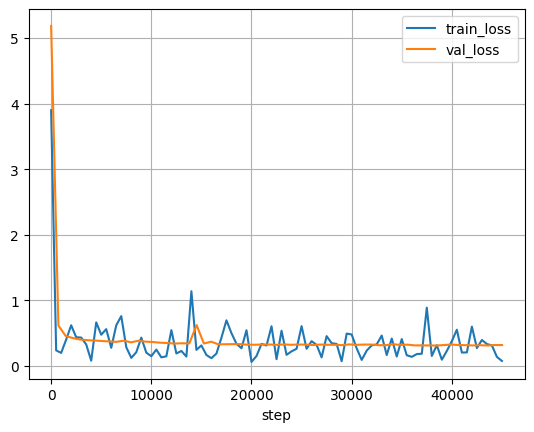

In [57]:
plot_learning_curves(record)  #横坐标是 steps

# 测试集

In [59]:
model.eval()
loss = evaluator(model, test_loader, loss_func)
print(f"loss:     {loss:.4f}")

loss:     0.3270
